<a href="https://colab.research.google.com/github/DanielaThais/analise-regressao-linear-python/blob/main/Daniela_Thais_dos_Santos_Rodrigues_Atividade_Ativa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Atividade Ativa - Aprendizagem de Máquina

#### Nome: Daniela Thais dos Santos Rodrigues
#### Matrícula: 2486101001
#### Professor: Ricardo Rocha
#### Curso: Análise e Desenvolvimento de Sistemas
#### Material usado: Dataset California Housing (sklearn.dataset)


---




# Regressão Linear com Python

## Objetivo
#### Esta atividade tem como objetivo aplicar a técnica de Regressão Linear utilizando Python no Google Colab, explorando um conjunto de dados e analisando os resultados obtidos.

#### Foi utilizado o dataset California Housing, disponível na biblioteca sklearn.datasets.



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
# Carregar dataset
dados = fetch_california_housing()

# Transformar em DataFrame
df = pd.DataFrame(dados.data, columns=dados.feature_names)

# Adicionar variável alvo
df['PrecoCasa'] = dados.target

# Exibir primeiras linhas
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,PrecoCasa
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [ ]:
# Informações gerais
df.info()

# Estatísticas descritivas
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   PrecoCasa   20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,PrecoCasa
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


## Análise Inicial dos Dados

O dataset apresenta informações relacionadas ao mercado imobiliário da Califórnia.

As estatísticas descritivas permitem observar:
- média dos valores;
- desvio padrão;
- valores mínimos e máximos;
- distribuição geral dos dados.

Essas informações ajudam a compreender o comportamento das variáveis antes da aplicação do modelo de regressão linear.

In [ ]:
# Variável independente
X = df[['MedInc']]

# Variável dependente
y = df['PrecoCasa']

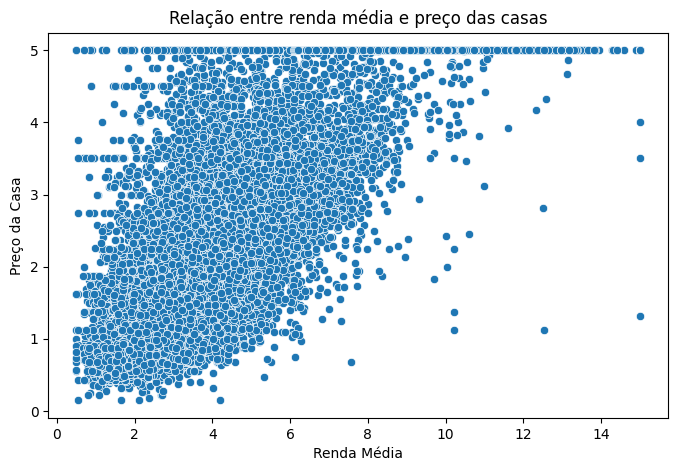

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(x=df['MedInc'], y=df['PrecoCasa'])

plt.title('Relação entre renda média e preço das casas')
plt.xlabel('Renda Média')
plt.ylabel('Preço da Casa')

plt.show()

## Visualização Exploratória

O gráfico de dispersão mostra uma relação positiva entre a renda média da população e o preço médio das casas.

Observa-se uma tendência aproximadamente linear, indicando que regiões com maior renda média tendem a possuir imóveis mais caros.

Isso sugere que a regressão linear pode ser adequada para modelar essa relação.

In [ ]:
# Separar dados treino e teste
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# Criar modelo
modelo = LinearRegression()

# Treinar modelo
modelo.fit(X_treino, y_treino)

LinearRegression()

In [ ]:
# Fazer previsões
y_pred = modelo.predict(X_teste)

In [ ]:
# Coeficiente angular
print("Coeficiente:", modelo.coef_[0])

# Intercepto
print("Intercepto:", modelo.intercept_)

# Erro médio quadrático
print("MSE:", mean_squared_error(y_teste, y_pred))

# R²
print("R²:", r2_score(y_teste, y_pred))

Coeficiente: 0.4193384939381271
Intercepto: 0.4445972916907879
MSE: 0.7091157771765549
R²: 0.45885918903846656


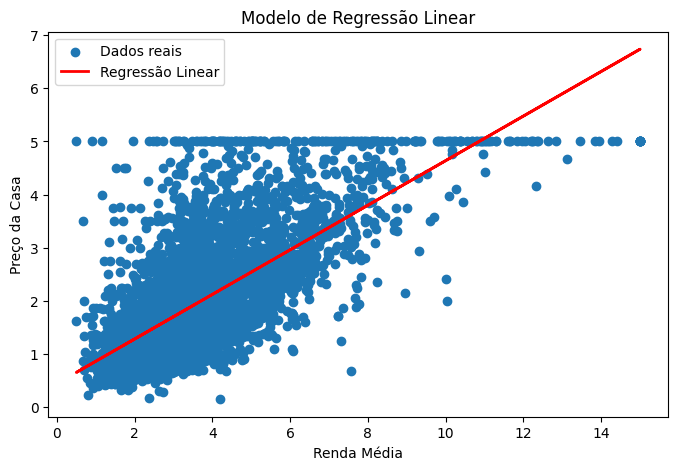

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(X_teste, y_teste, label='Dados reais')

plt.plot(X_teste, y_pred, color='red', linewidth=2, label='Regressão Linear')

plt.xlabel('Renda Média')
plt.ylabel('Preço da Casa')

plt.title('Modelo de Regressão Linear')

plt.legend()

plt.show()

## Interpretação dos Resultados

O modelo de regressão linear foi capaz de identificar uma relação positiva entre a renda média da população e o preço das casas.

O coeficiente da regressão indica que, conforme a renda média aumenta, o preço médio dos imóveis também tende a aumentar.

O valor de R² mostra o quanto o modelo consegue explicar a variação dos preços das casas. Quanto mais próximo de 1, melhor o desempenho do modelo.

A visualização da reta de regressão demonstra que o modelo acompanha a tendência geral dos dados, embora existam algumas dispersões naturais.

---
## Conclusão

#### A atividade permitiu compreender na prática o funcionamento da Regressão Linear utilizando Python no Google Colab.

Foi possível:
- explorar os dados;
- visualizar relações entre variáveis;
- treinar um modelo de regressão linear;
- interpretar métricas e resultados.

#### A técnica de regressão linear é importante na Aprendizagem de Máquina por permitir prever valores e identificar padrões em conjuntos de dados.